# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
display(plans.head(5))

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
display(users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
display(usage.head(5))

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:

# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("\nNulos en users")
print(users.isna().sum())


Nulos en users
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [11]:
# cantidad de nulos para usage
print("\nNulos en usage")
print(usage.isna().sum())


Nulos en usage
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- #### Dataset users
- Encontramos en la columna 'city' 469 valores nulos los cual representa el 11.7%
- En la columna 'churn_date' presenta 3534 valores nulos el 88.4%
- #### Dataset usage
- La columna 'date' tiene un total de 50 valores nulos
- 'duration' y 'length' tienen 22076 (55%) y 17896 (44.7 %) respectivamente.
- Indica qué harías: ¿imputar, eliminar, ignorar?
- En users la columna city se debe imputra ya que perderimaos el 11% de los registros con información que pude ser util.
- chur_date aunque tiene alto porcentaje, esto nos indica cuales son los clientes que aún no han cancelado el servicio por lo tanto esto no reprsntan necesariamente un problema, se pude ignorar.
- date se podria eliminar o imputar ya que no es representativo para el analisis.
- 'duration' y 'length' validar si los nulos corresponden al tipo de evento (`type`) antes de imputar o eliminar datos.
  

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` presneta valores consisitentes con una variacion dispersa pero sin valores inusuales.
- La columna `age`prsneta un valor minimo de -999, lo cual represneta un sentinel o valor invalido, los cual nos indica que existen valores faltantes o errores de registro.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` presnetan valores positivos y consistentes, sin anomalias aparentes
- La columna `duration` presenta duraciones válidas, sin valores negativos. Existen llamadas de hasta 120 minutos, que podrían revisarse posteriormente como posibles outliers.
- - La columna `length` presenta valores entre 0 y 1490 caracteres. Los valores altos podrían corresponder a mensajes extensos y serán evaluados durante el análisis de outliers.
- Se observa una diferencia importante entre la cantidad total de registros y los valores no nulos en `duration` y `length`. Esto probablemente se debe a que las filas representan distintos tipos de actividad (`call` y `message`), donde solo una de las variables aplica en cada caso

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print("\nValores unicos de {col}:")
    print(users[col].value_counts())


Valores unicos de {col}:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores unicos de {col}:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` no presenta inconsistencias por diferencias de mayúsculas o minúsculas. Sin embargo, se identifican 96 registros con el valor `"?"`, el cual representa un posible valor inválido o dato faltante. Este valor deberá ser tratado durante la etapa de limpieza de datos.
- La columna `plan` no presenta anomalías ni categorías inesperadas. Se observa que la mayoría de los clientes se encuentran asociados al plan `Basico`.

In [15]:
# explorar columna categórica de usage
usage['type'] # completa el código
print("Valores únicos de type")
print(usage['type'].value_counts())


Valores únicos de type
text    22092
call    17908
Name: type, dtype: int64


- - La columna `type` presenta únicamente las categorías esperadas para el tipo de actividad registrada (`call` y `message`), sin inconsistencias aparentes ni errores de escritura.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

Se identificaron valores inválidos o sentinels en las columnas `age` y `city`.

- En `age` se detectó el valor `-999`, el cual representa un valor imposible y probablemente fue utilizado como sentinel para indicar datos faltantes o errores de registro.

- En `city` se identificó la categoría `"?"`, la cual no corresponde a una ciudad válida y representa aproximadamente el 2.4% de los registros.

- ¿Qué acción tomarías?

- Para la columna `city`, se recomienda reemplazar el valor `"?"` por `NaN` y posteriormente analizar la mejor estrategia de tratamiento. No se recomienda eliminar los registros debido a la posible pérdida de información valiosa, ni imputar con una ciudad existente, ya que esto podría generar sesgos o aumentar artificialmente la frecuencia de alguna categoría.

- Para la columna `age`, se recomienda reemplazar el sentinel `-999` por `NaN` y posteriormente imputar los valores faltantes utilizando la mediana, debido a que es una medida más robusta frente a posibles valores atípicos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] =pd.to_datetime(users['reg_date'], errors ='coerce') # completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors= 'coerce')# completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date` se identificaron 40 registros correspondientes al año 2026. Debido a que el dataset indica que la información recopilada llega únicamente hasta el año 2024, estos registros representan fechas fuera de rango y probablemente corresponden a errores de captura o inconsistencias en los datos.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, En la columna `date` se identificaron 39,950 registros correspondientes al año 2024. La diferencia frente al total de registros del dataset se debe a 50 valores nulos o inválidos que fueron convertidos a `NaT` durante la transformación al tipo datetime utilizando `errors='coerce'`. 
<!-- Basaremos el análisis en estas fechas. -->

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

- Sí, en la columna reg_date aparecen 40 registros del año 2026, lo cual es imposible dentro del contexto del dataset porque nos dijeron que la información solo llega hasta 2024.
- En la columna date de usage no aparecen años fuera de rango, todos los registros válidos pertenecen a 2024.
- ¿Qué harías con ellas?


- Para `reg_date`, se recomienda revisar los registros del año 2026 para validar si se trata de errores de digitación. Si no es posible identificar la fecha correcta, estos valores deberían convertirse en `NaT` o excluirse del análisis temporal.

Para `date`, se recomienda excluir los registros con `NaT` del análisis temporal, ya que no permiten ubicar correctamente la actividad en el tiempo.
- Se recomienda revisar los registros correspondientes al año 2026 para validar si se trata de errores de digitación. En caso de no poder identificar la fecha correcta, estos valores deberían convertirse en `NaT` o excluirse del análisis temporal para evitar sesgos en el estudio.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
users['age']=users['age'].replace(-999,np.nan)
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city']= users['city'].replace('?', np.nan)
# imputamos nolos con unknown
users['city']= users['city'].fillna('Unknown')

# Verificar cambios
print(users['city'].value_counts())

Bogotá      808
CDMX        730
Medellín    616
Unknown     565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
# Verificar cambios
print(users['reg_date'].dt.year.value_counts().sort_index())
print(users['reg_date'].isna().sum())

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64
40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).sum()

type
call        0
text    22076
Name: duration, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).sum()

type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`


-Se observa que los valores nulos en `duration` y `length` dependen directamente de la columna `type`.

- Los registros de tipo `call` no presentan nulos en `duration`, pero sí en `length`, ya que una llamada no tiene longitud de texto.
- Los registros de tipo `text` no presentan nulos en `length`, pero sí en `duration`, ya que un mensaje no tiene duración.

Esto confirma que los valores nulos no corresponden a errores de captura, sino a la naturaleza del tipo de actividad registrada. Por esta razón, se decide mantener estos valores como nulos, ya que imputarlos introduciría información artificial en variables que no aplican.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    "is_text":'sum',
    'is_call':'sum',
    'duration':'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg.columns =[
    'user_id',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,Unknown,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
(user_profile['plan'].value_counts(normalize=True) * 100).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

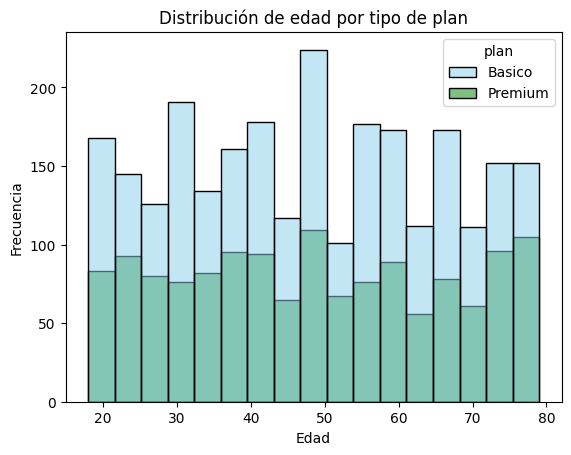

In [30]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x = 'age',hue ='plan', palette=['skyblue','green'])
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- La distribución de edades presenta un comportamiento relativamente uniforme, sin un sesgo marcado hacia edades jóvenes o mayores. No se observan diferencias significativas entre los usuarios de los planes Basic y Premium, lo que sugiere que la edad no parece ser un factor determinante en la elección del plan. Además, no se identifican valores extremos o edades fuera de rango.

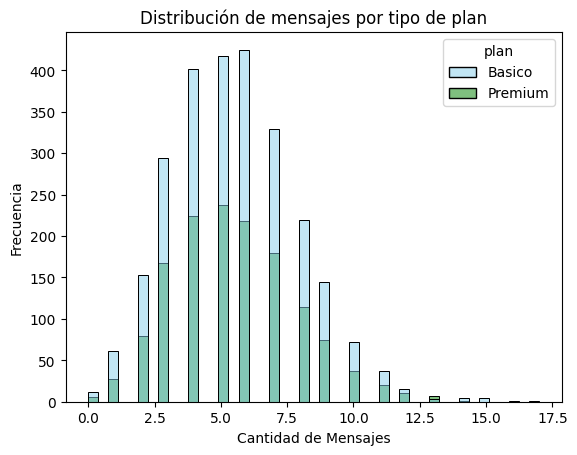

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x = 'cant_mensajes',hue ='plan', palette=['skyblue','green'])
plt.title('Distribución de mensajes por tipo de plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- La distribución de mensajes presenta un sesgo hacia la derecha, ya que la mayoría de usuarios se concentra entre 3 y 8 mensajes, mientras que pocos usuarios registran cantidades mucho mayores. No se observan diferencias significativas en el patrón de uso entre los planes Basic y Premium, ya que ambas distribuciones muestran una forma similar, aunque el plan Basic presenta mayor frecuencia debido a su mayor número de usuarios.

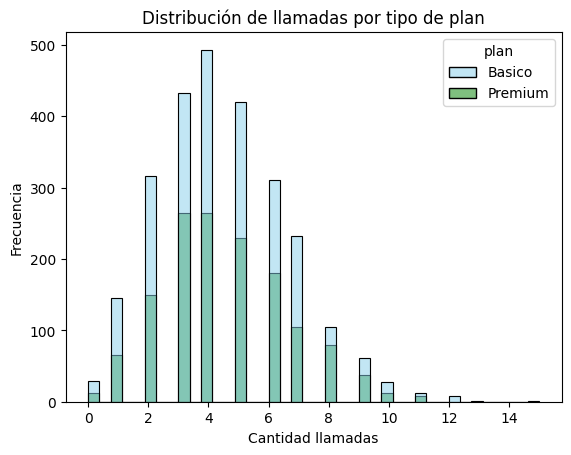

In [32]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x = 'cant_llamadas',hue ='plan', palette=['skyblue','green'])
plt.title('Distribución de llamadas por tipo de plan')
plt.xlabel('Cantidad llamadas')
plt.ylabel('Frecuencia')
plt.show()



💡Insights: 
- La distribución de llamadas presenta un sesgo hacia la derecha, ya que la mayoría de usuarios se concentra entre 2 y 7 llamadas, mientras que pocos usuarios registran cantidades más altas, alcanzando hasta 15 llamadas. No se observan anomalías extremas, aunque sí una cola de usuarios con mayor uso. En cuanto al tipo de plan, tanto Basic como Premium presentan una distribución similar, concentrándose en rangos parecidos de llamadas, sin diferencias marcadas en el patrón de comportamiento

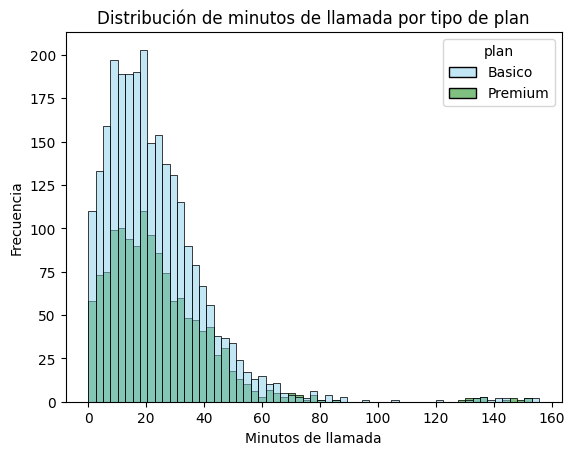

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x = 'cant_minutos_llamada',hue ='plan', palette=['skyblue','green'])
plt.title('Distribución de minutos de llamada por tipo de plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()



💡Insights: 
- La distribución de minutos de llamada presenta un fuerte sesgo hacia la derecha, ya que la mayoría de usuarios se concentra en rangos bajos y moderados de consumo (aproximadamente entre 5 y 35 minutos), mientras que pocos usuarios registran consumos muy altos, alcanzando valores cercanos a 150 minutos. Tanto el plan Basic como Premium muestran un comportamiento similar en la forma de la distribución, aunque no es posible concluir únicamente con este histograma cuál plan consume más en total, ya que el plan Basic cuenta con un mayor número de usuarios.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

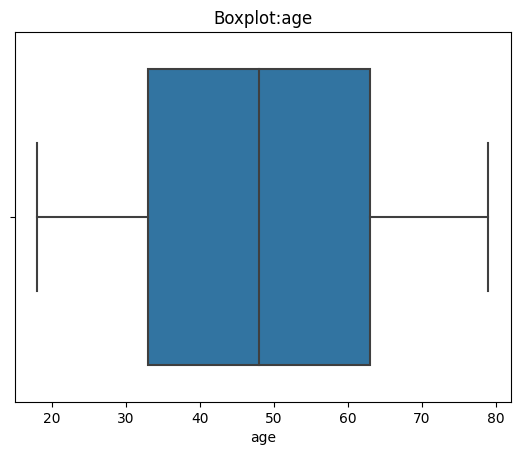

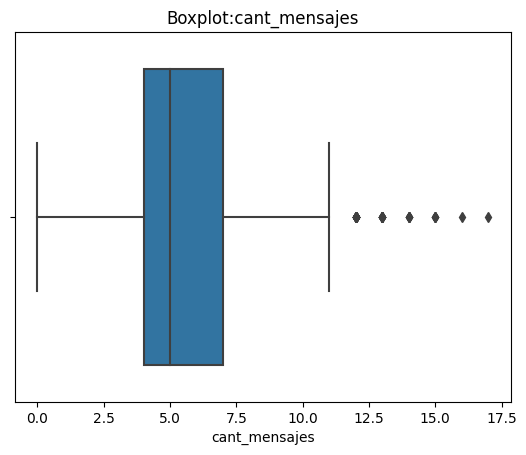

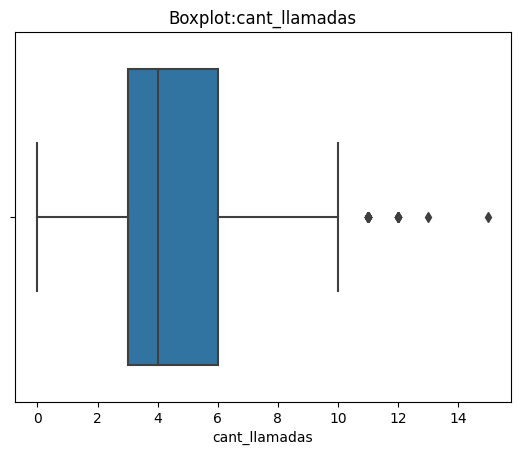

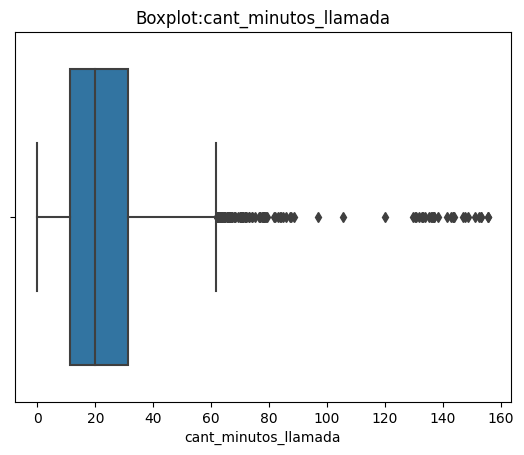

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x =user_profile[col])
    plt.title(f'Boxplot:{col}')
    plt.show()

💡Insights: 
- Age: La variable age no presenta outliers visibles según el boxplot. La distribución de edades se encuentra dentro de rangos esperados, con una mediana cercana a los 47 años y una dispersión relativamente equilibrada, por lo que no se requiere tratamiento adicional para esta variable.
  
- cant_mensajes: La variable cant_mensajes presenta outliers superiores, observados en usuarios con aproximadamente entre 12 y 17 mensajes. Sin embargo, estos valores no parecen errores de registro, sino usuarios con un nivel de uso más alto que el promedio. No se observan outliers inferiores, por lo que no se recomienda eliminarlos por el momento.

  
- cant_llamadas:La variable cant_llamadas presenta outliers superiores, observados en usuarios con aproximadamente entre 11 y 15 llamadas. No se identifican outliers inferiores. Estos valores no parecen corresponder a errores de registro, sino a usuarios con un mayor nivel de uso, por lo que no se recomienda eliminarlos del análisis.


- cant_minutos_llamada:La variable cant_minutos_llamada presenta numerosos outliers superiores, observados a partir de aproximadamente 65 minutos y alcanzando valores cercanos a 160 minutos. No se identifican outliers inferiores. Aunque estos valores son extremos según el boxplot, no parecen corresponder a errores de captura, sino a usuarios con un consumo elevado de minutos, lo cual es consistente con el comportamiento esperado en este tipo de servicio. Por esta razón, no se recomienda eliminarlos sin un análisis adicional.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3-Q1
    limite_superior = Q3 +1.5*IQR

    print(f'{col}')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Límite superior: {limite_superior}')
    print('-------------------')



cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5
-------------------
cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5
-------------------
cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575
-------------------


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- El límite superior calculado con IQR fue 11.5, por lo que valores superiores a este se consideran outliers. Sin embargo, dado que el máximo observado (17) no representa un valor imposible, se recomienda mantenerlos, ya que corresponden a usuarios con mayor actividad
  
- cant_llamadas: mantener o no outliers, porqué?
- El límite superior fue 10.5, identificándose como outliers los valores superiores a este umbral. No obstante, el máximo observado (15) sigue siendo razonable dentro del contexto de uso del servicio, por lo que se recomienda conservarlos.

- cant_minutos_llamada: mantener o no outliers, porqué?
- El límite superior fue 61.86, detectándose varios outliers superiores. Aunque el máximo alcanza aproximadamente 160 minutos, estos valores pueden corresponder a usuarios de alto consumo y no necesariamente a errores de registro. Se recomienda mantenerlos para conservar el comportamiento real del dataset.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
grupo_uso = []

for i in range(len(user_profile)): # usamos el len para contar cada uno de los elementos 
    llamadas = user_profile.loc[i, 'cant_llamadas'] # aplicamos loc para filtrar filas 
    mensajes = user_profile.loc[i, 'cant_mensajes']

    if llamadas < 5 and mensajes < 5:
        grupo_uso.append('Bajo uso')

    elif llamadas < 10 and mensajes < 10:
        grupo_uso.append('Uso medio')

    else:
        grupo_uso.append('Alto uso')

# Crear columna
user_profile['grupo_uso'] = grupo_uso


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,Unknown,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
grupo_edad = []
for i in range (len(user_profile)):
    edad = user_profile.loc[i, 'age']

    if edad < 30:
        grupo_edad.append('Joven')

    elif edad < 60:
        grupo_edad.append('Adulto')

    else:
        grupo_edad.append('Adulto Mayor')

# crear columna 

user_profile['grupo_edad'] = grupo_edad   


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,Unknown,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

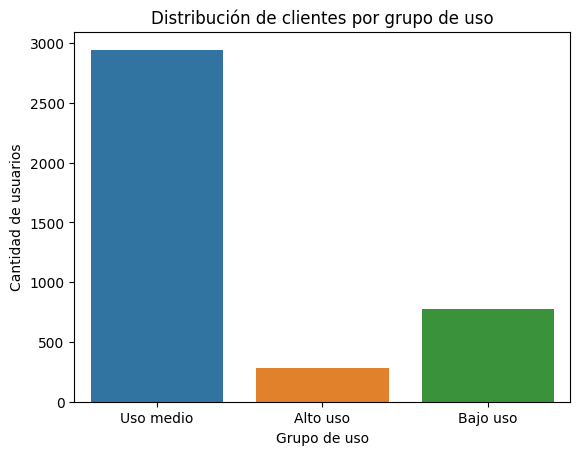

In [41]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

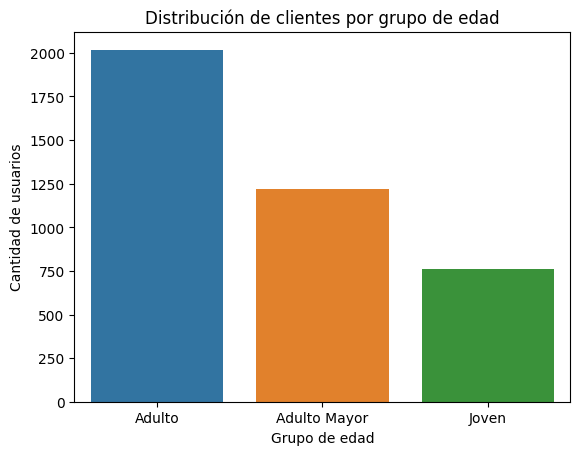

In [42]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

- Durante la etapa de calidad de datos se identificaron varios problemas:

En city se encontraron 96 registros con el valor sentinel ?, equivalentes al 2.4% del dataset users. Estos fueron tratados como valores faltantes y posteriormente imputados como Unknown, ya que eliminar estos registros implicaba pérdida de información valiosa.
En age se detectaron valores inválidos con el sentinel -999, los cuales no representaban edades reales. Estos fueron reemplazados por NaN y posteriormente imputados con la mediana, por ser una medida robusta frente a valores extremos.
En reg_date se identificaron 40 registros con fechas en el año 2026, aunque el dataset solo debía contener información hasta 2024. Estos registros fueron marcados como NaT al considerarse fechas fuera de rango.
En usage.date se detectaron 50 valores inválidos o faltantes, que fueron convertidos a NaT usando errors='coerce'.
En duration y length se encontraron nulos, pero el análisis mostró que dependían del tipo de registro (call o text), por lo que se concluyó que eran nulos esperados (MAR) y no errores de captura.


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

- Segmentación por uso:
Uso medio: aproximadamente 2950 usuarios, siendo el segmento dominante.
Bajo uso: aproximadamente 780 usuarios.
Alto uso: aproximadamente 280 usuarios.

Esto indica que la mayoría de clientes presenta un comportamiento de consumo moderado, mientras que existe un grupo reducido de usuarios intensivos.

Segmentación por edad:
Adultos: aproximadamente 2000 usuarios, siendo el grupo predominante.
Adulto Mayor: aproximadamente 1220 usuarios.
Jóvenes: aproximadamente 760 usuarios.

Esto muestra que la base principal de clientes está concentrada en usuarios adultos, con menor participación del segmento joven.


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
- El segmento más valioso potencialmente corresponde a los usuarios de Alto uso, aunque representan una proporción pequeña de la base. Estos clientes generan mayor consumo de llamadas, mensajes y minutos, lo que puede traducirse en mayores ingresos y oportunidades de planes premium.

El segmento de Uso medio también es estratégico, ya que representa la mayor parte de la base de clientes y constituye el núcleo del negocio. Pequeñas mejoras en este grupo pueden generar impactos significativos.

Los usuarios de Bajo uso requieren atención, ya que podrían representar riesgo de baja interacción o churn, aunque también ofrecen oportunidades de activación mediante campañas específicas.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

- Se detectaron outliers superiores en:

cant_mensajes (valores > 11.5)
cant_llamadas (valores > 10.5)
cant_minutos_llamada (valores > 61.86)

Estos outliers corresponden principalmente a usuarios con un nivel de consumo significativamente superior al promedio.

Sin embargo, no se consideran errores de captura, ya que los valores máximos observados siguen siendo plausibles dentro del contexto del negocio.

Desde el punto de vista comercial, estos usuarios pueden representar:

clientes de alto valor
heavy users
oportunidades para planes especializados o upgrades


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
- Diseñar ofertas para usuarios de Alto uso, incluyendo planes con mayores beneficios en llamadas y mensajes, orientados a retener clientes intensivos.
-Implementar campañas de activación para usuarios de Bajo uso, con promociones o beneficios que incentiven un mayor consumo y reduzcan riesgo de abandono.
-Optimizar el plan base para usuarios de Uso medio, ya que representan la mayoría de la base y pequeños ajustes podrían mejorar la satisfacción y fidelización.
-Crear estrategias comerciales para atraer usuarios jóvenes, dado que es el segmento demográfico menos representado.
-Monitorear continuamente a los heavy users, para entender mejor sus patrones y desarrollar productos diferenciados que maximicen ingresos.




✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores inválidos en variables como age, city y fechas (reg_date, usage.date), que fueron tratados como valores faltantes y corregidos
- Los nulos en duration y length no se consideraron errores, ya que dependen del tipo de registro (call o text) y representan un comportamiento esperado.

🔍 **Segmentos por Edad**
- El segmento predominante corresponde a Adultos, seguido de Adultos Mayores, mientras que los Jóvenes representan la menor proporción de usuarios.
- Esto indica que la base principal de clientes está concentrada en usuarios de edad media, con oportunidad de crecimiento en segmentos jóvenes.


📊 **Segmentos por Nivel de Uso**
- La mayoría de clientes pertenece al grupo de Uso medio, seguido de Bajo uso, mientras que el segmento de Alto uso es el más pequeño.
- Esto muestra que la empresa depende principalmente de usuarios con consumo moderado, aunque existe un grupo reducido de clientes intensivos de alto valor.


➡️ Esto sugiere que 
ConnectaTel tiene una base de clientes estable concentrada en usuarios adultos de consumo medio, pero existen oportunidades para mejorar la captación de usuarios jóvenes y desarrollar ofertas específicas para clientes de alto consumo


💡 **Recomendaciones**
- Diseñar estrategias comerciales para fortalecer el segmento de Uso medio, que representa la mayor parte de la base.
- Crear planes o beneficios diferenciados para usuarios de Alto uso y campañas de activación para clientes de Bajo uso.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`